# CodeLab 3: Classifacton of WLANs power saving

Energy management is important for electronic devices, and doubly so for portable systems that run on battery power. For this Code Lab, we consider the problem of controlling the power state of the wireless network interface controller. For optimal performance, this power state should adapt to the network usage. We will use a dataset published alongside a paper by Saeed and Kolberg, 2018. The researchers measured the traffic signatures associated with a number of applications, on a mobile phone and labelled each according to the WLAN usage pattern. The dataset comprises 1350 samples with 6 features and a single classification label. The label (the type of usage) was assigned one of four categories: high, varied, buffer, or low. 

<br> In this Codelab we will start with binary classification, in which we will see the difference between weighted and non-weighted binary classification. Secondly, we will develop some multiclass models. There we will see the difference between one-versus-all  and multinomial classification. Various classification metrics will be used to assess the models’ prediction capabilities. 



In [343]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [344]:
# Import packages needed for the lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_curve, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score, RocCurveDisplay, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

<br> In this lab, we will work on different classifiers for different classification models. Even though the data is already prepared, it is important to get familiar with the data you will work with. 
<br> −Load “Network_Traffic.csv” into Pandas data frame. 

In [345]:
# Import the data and visualize it
data = pd.read_csv('Network_Traffic.csv', delimiter=',')
data
#print(data.columns)

,Receiving-data-rate-in-Kbytes-per-seconds,Transmitting-data-rate-in-Kbytes-per-seconds,Total-received-Kbytes,Total-Transmitted-Kbytes,Total-received-packets,Total-Transmitted-packets,Class
0,78.66,87.02,974.37,1000.00,1640,1540,High
1,94.52,91.51,1800.00,1870.00,3240,3040,High
2,69.89,76.95,2800.00,2900.00,5080,4700,High
3,131.25,156.25,3970.00,4140.00,7690,6760,High
4,106.64,115.82,4840.00,5070.00,9810,8400,High
...,...,...,...,...,...,...,...
1345,21.19,0.55,25000.00,439.16,19460,8410,Buffer
1346,11.28,0.10,25150.00,441.95,19580,8460,Buffer
1347,22.98,0.30,25310.00,444.59,19710,8520,Buffer
1348,25.00,0.10,25400.00,445.98,19770,8540,Buffer


## Task 1 - Data Preparation

<br> - 	Split the data frame into features data frame X and label data frame y.

In [346]:
# Seperate features from classes
X = data.drop(columns=[' Class'])
y = data[' Class']

-Calculate and print the correlation matrix of X.

In [347]:
#Correlation matrix
corrMatrix = X.corr()
print(corrMatrix)
print(corrMatrix.shape)

                                               Receiving-data-rate-in-Kbytes-per-seconds  \
Receiving-data-rate-in-Kbytes-per-seconds                                       1.000000   
 Transmitting-data-rate-in-Kbytes-per-seconds                                   0.748078   
 Total-received-Kbytes                                                          0.643117   
 Total-Transmitted-Kbytes                                                       0.591491   
 Total-received-packets                                                         0.636381   
 Total-Transmitted-packets                                                      0.496000   

                                                Transmitting-data-rate-in-Kbytes-per-seconds  \
Receiving-data-rate-in-Kbytes-per-seconds                                           0.748078   
 Transmitting-data-rate-in-Kbytes-per-seconds                                       1.000000   
 Total-received-Kbytes                                             

-Plot the heat map of correlation matrix X using the Seaborn library (heatmap). 

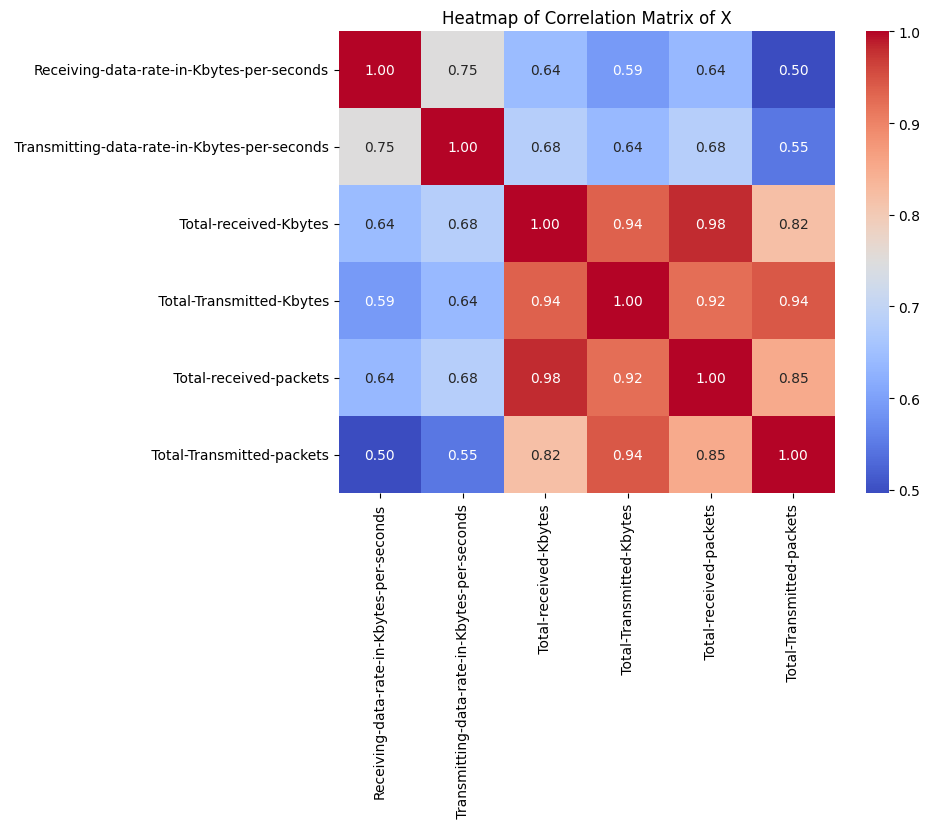

In [348]:
#Heatmap
plt.figure(figsize=(8, 6))
sn.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap of Correlation Matrix of X")
plt.savefig("task1_heatmap.png",bbox_inches = 'tight')
plt.show()

−Plot the 2 variables with the most correlation in a scatter plot.

(' Total-received-Kbytes', ' Total-received-packets')


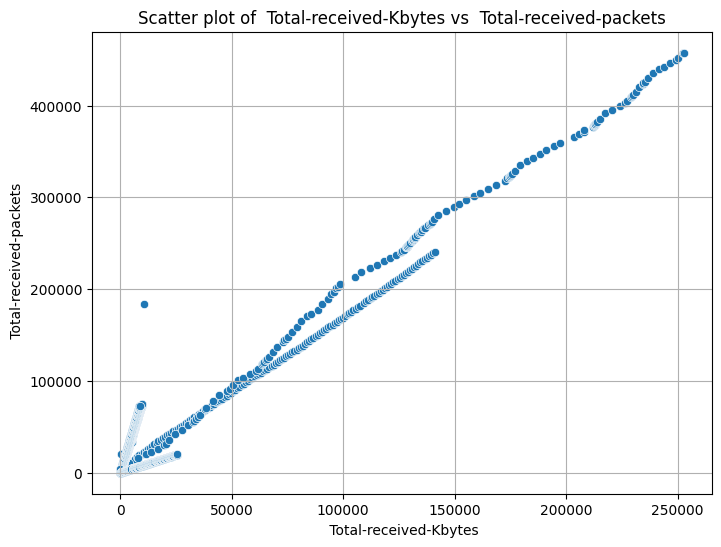

In [349]:
mask = np.eye(corrMatrix.shape[0], dtype=bool) # diagonal is masked because self corr. is 1 
corrMatrix_no_diag = corrMatrix.where(~mask)
#print(corrMatrix_no_diag)
max_corr_pair = corrMatrix_no_diag.unstack().idxmax() # index of the max correlation
print(max_corr_pair)
var1, var2 = max_corr_pair # extract
#Scatter plot
plt.figure(figsize=(8, 6))
sn.scatterplot(x=X[var1], y=X[var2])
plt.title(f"Scatter plot of {var1} vs {var2}")
plt.xlabel(var1)
plt.ylabel(var2)
plt.grid()
plt.savefig("task1_scatter.png",bbox_inches = 'tight')          
plt.show()

-Create an array named “y_2c” for two class classification. Convert the samples with the high label as 1 and the rest as 0. 

In [350]:
# Creat one-versus-all with High as 1, all other are labeled 0
y_2c = (y == 'High').astype(int)

−	Calculate the ratio of high-class samples to all samples. 

In [351]:
high_class_count = (y == 'High').sum()
total_samples = len(y)
#Ratio of high-class 
ratio = high_class_count / total_samples
print('Ratio of high-class samples to all samples:',ratio)
print(high_class_count)

Ratio of high-class samples to all samples: 0.4444444444444444
600


-Create an array named “y_mc” that can be used for multiclass classification. Use numerical labels according to the class, as follows: 3-High, 2-Varied, 1-Low, 0-Buffer.

In [352]:
class_dic = {
    'High': 3,
    'Varied': 2,
    'Low': 1,
    'Buffer': 0}
# Create the Multi class y vector
y_mc = data[' Class'].map(class_dic)
print(y_mc)

0       3
1       3
2       3
3       3
4       3
       ..
1345    0
1346    0
1347    0
1348    0
1349    0
Name:  Class, Length: 1350, dtype: int64


−	Plot the distribution of labels in the data set using a bar plot. 

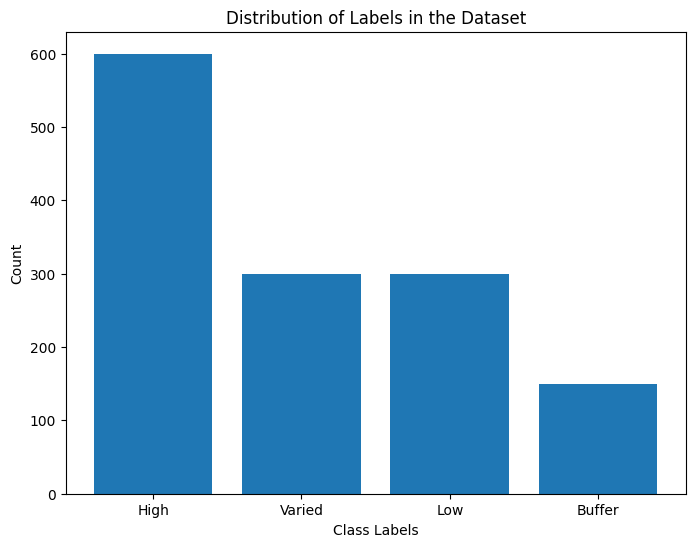

In [353]:
#Plot the distribution of labels.
c_high = (y_mc == 3).sum()  
c_var = (y_mc == 2).sum()   
c_low = (y_mc == 1).sum()   
c_buff = (y_mc == 0).sum() 
plt.figure(figsize=(8, 6))
plt.bar(['High', 'Varied', 'Low', 'Buffer'], [c_high, c_var, c_low, c_buff])
plt.title("Distribution of Labels in the Dataset")
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.savefig("task1_bar.png",bbox_inches = 'tight')     
plt.show()

-Convert data frames X, y_2c, and  y_mc  to NumPy arrays (if they were Pandas objects). Convert the label vector elements to integers using the following notation, y.astype(‘int’), where y is the label vector.  

In [354]:
# Convert to array
y_2c_data = y_2c.to_numpy()
y_mc_data = y_mc.to_numpy()
X_data = X.to_numpy()
y_2c_data_int = y_2c_data.astype('int')
y_mc_data_int = y_mc_data.astype('int')

-Scale the feature matrix X with the StandardScaler() function from Sklearn. 	

In [355]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

Questions:
<br> 1) Which variables have the highest correlation? Does this make sense to you? Why?
<br> 2) What is the ratio of high-class labels in binary classification?
<br> 3) What is the share of each label in multiclass classification?
<br>4) Why might scaling improve the prediction capability of machine learning?


In [356]:
# Total number of samples
total_samples = c_high + c_var + c_low + c_buff

# Proportions of each class
prop_high = c_high / total_samples
prop_var = c_var / total_samples
prop_low = c_low / total_samples
prop_buff = c_buff / total_samples

# Print the results
print(f"Proportion of 'High' class (3): {prop_high:.4f}")
print(f"Proportion of 'Varied' class (2): {prop_var:.4f}")
print(f"Proportion of 'Low' class (1): {prop_low:.4f}")
print(f"Proportion of 'Buffer' class (0): {prop_buff:.4f}")

Proportion of 'High' class (3): 0.4444
Proportion of 'Varied' class (2): 0.2222
Proportion of 'Low' class (1): 0.2222
Proportion of 'Buffer' class (0): 0.1111


## Task 2: Binary classification with Logistic Regression

In the second task, you will develop a binary classifier (one versus all) to detect whether the wireless network is operating in high consumption mode or not. ML models will be tested based on 25% of the input data. You are free to develop your own functions using Sklearn functions for tasks like training, predicting, or performance evaluation. 

−	Split the data into training and test sets using the “train_test_split” function from Sklearn. Use 4720 as the random state parameter to control the split. 

In [357]:
#Train test split (use the binary classificaiton so y_2c ones)
Shuffle_state = 4720
X_train_2c, X_test_2c, y_train_2c, y_test_2c = train_test_split(X_scaled, y_2c_data_int, test_size=0.25, random_state=4720, shuffle=True)

<br>−Develop and train a logistic regression model with default parameters. 
<br>−Use the trained model to predict test labels. 

In [358]:
#Logistic regression
clf_lr = LogisticRegression() #classifier logistic regression, with default parameters where max_iter=100 on default
clf_lr.fit(X_train_2c, y_train_2c) #train the model on the training data
y_prediction = clf_lr.predict(X_test_2c) #use trained model to predict test labels
#print("Predicted test labels:", y_prediction)
#ratio_ones = (y_prediction == 1).sum() / len(y_prediction)
#print(f"Ratio of ones in y_prediction: {ratio_ones:.4f}")
#print(len(y_prediction))

−Calculate and print the following performance metrics: Accuracy, recall, precision, and F1 score.

In [359]:
#Performance metrics
Accuracy_LR = accuracy_score(y_test_2c, y_prediction)
F1_LR = f1_score(y_test_2c, y_prediction)
Precision_LR = precision_score(y_test_2c, y_prediction)
Recall_LR = recall_score(y_test_2c, y_prediction)
print("Accuracy: " + str(Accuracy_LR))
print("F1 score: " + str(F1_LR))
print("Recall score: " + str(Recall_LR))
print("Precision score: " + str(Precision_LR))

Accuracy: 0.9378698224852071
F1 score: 0.9292929292929293
Recall score: 0.8679245283018868
Precision score: 1.0


−Plot the receiver operating characteristics (ROC) curve of training and test data in the same figure. By default, the logistic regression model uses a cut-off value of 0.5 to assign a positive or negative prediction to a data point. Different values can be used to bias the prediction towards negative or positive outcomes. The ROC curve plots the combinations of specificity and recall (sensitivity) that result from a range of cut-off values. 

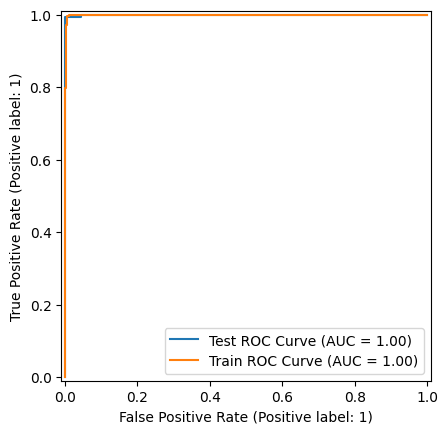

In [360]:
ax = plt.gca()
test_disp = RocCurveDisplay.from_estimator(clf_lr, X_test_2c, y_test_2c, ax=ax, name="Test ROC Curve")
train_disp = RocCurveDisplay.from_estimator(clf_lr, X_train_2c, y_train_2c, ax=ax, name="Train ROC Curve")
plt.savefig("task2_roc.png",bbox_inches = 'tight')   
plt.show()

−Generate and plot the confusion matrix.

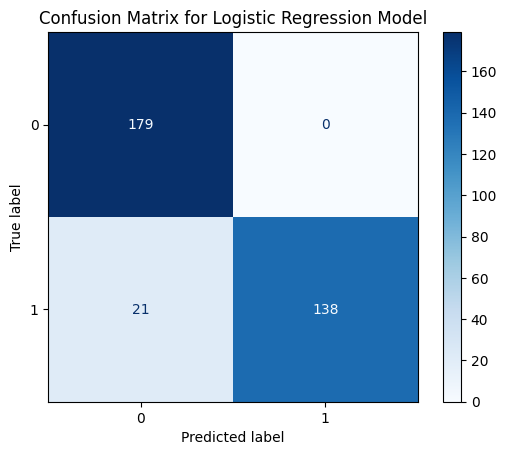

In [361]:
#Confusion Matrix
cm = confusion_matrix(y_test_2c, y_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Model")
plt.savefig("task2_confusion.png",bbox_inches = 'tight') 
plt.show()

The class weight parameter adjusts the penalization factor of misclassified examples in model training. Depending on the application selection of weights varies. For example, in medical testing, the cost of false negatives (absence of a disease when it is present) outweighs the cost of false positives (incorrect indication of a disease when it is not present). In this binary classification, we need to modify the weights to reduce the number of missed high cases (false negatives).
<br> -Develop and train a logistic regression model using the “class_weight” parameter to reduce the number of false negatives in the test data (y_(2c_test)=1, but y_pred = 0). (Tip: In CodeLab2, we had constructed a SVM grid search. Similar to that, you don't have to try all the combinations yourself, you can build a nested loop and add a judgment statement at the end until you have a suitable result)
<br> -Print out the selected weights. 


In [362]:
# Define possible weight ranges to explore
weight_values = [0.01, 0.1, 0.5, 1, 2, 3, 5, 7.5, 10]   # Adjust this range based on how fine-grained you want the search

best_w0 = None
best_w1 = None
lowest_fn = float('inf')  # Start with a very high false negatives count

# Loop over potential class weights
for w_0 in weight_values:
    for w_1 in weight_values:
        # Define class weights for the model
        class_weights = {0: w_0, 1: w_1}

        # Train the logistic regression model with these weights
        clf_lr_w = LogisticRegression(class_weight=class_weights)
        clf_lr_w.fit(X_train_2c, y_train_2c)

        # Predict on the test set
        y_prediction_w = clf_lr_w.predict(X_test_2c)

        # Calculate the confusion matrix
        cm = confusion_matrix(y_test_2c, y_prediction_w)

        # Extract false negatives (FN)
        fn = cm[1, 0]  # True label is 1, but predicted as 0 (FN)

        # Check if this configuration reduces false negatives
        if fn < lowest_fn:
            lowest_fn = fn
            best_w0 = w_0
            best_w1 = w_1

# Print the best found weights
print("Best weight for class 0 (w_0):", best_w0)
print("Best weight for class 1 (w_1):", best_w1)
# Train the final model with the best weights
clf_lr_w_final = LogisticRegression(class_weight={0: best_w0, 1: best_w1})
clf_lr_w_final.fit(X_train_2c, y_train_2c)

# Predict on the test set with the final model
y_prediction_w_final = clf_lr_w_final.predict(X_test_2c)

# Print the final confusion matrix
#cm_final = confusion_matrix(y_test_2c, y_prediction_w_final)
#print("Final Confusion Matrix:\n", cm_final)

Best weight for class 0 (w_0): 0.01
Best weight for class 1 (w_1): 0.1


In [363]:
#Weighted logistic regression
w_0 = ...
w_1 = ...
clf_lr_w = ...
y_prediction_w =...
print(w_0)
print(w_1)

Ellipsis
Ellipsis


−Calculate and print the following performance metrics: Accuracy, recall, precision, and F1 score.

In [364]:
#Performance metrics
Accuracy_LRw = accuracy_score(y_test_2c, y_prediction_w_final)
F1_LRw = f1_score(y_test_2c, y_prediction_w_final)
Precision_LRw = precision_score(y_test_2c, y_prediction_w_final)
Recall_LRw = recall_score(y_test_2c, y_prediction_w_final)
print("Accuracy: " + str(Accuracy_LRw))
print("F1 score: " + str(F1_LRw))
print("Recall score: " + str(Recall_LRw))
print("Precision score: " + str(Precision_LRw))

Accuracy: 0.47041420118343197
F1 score: 0.6398390342052314
Recall score: 1.0
Precision score: 0.47041420118343197


−Plot receiver operating characteristics (ROC) curve of training and test data in the same figure.

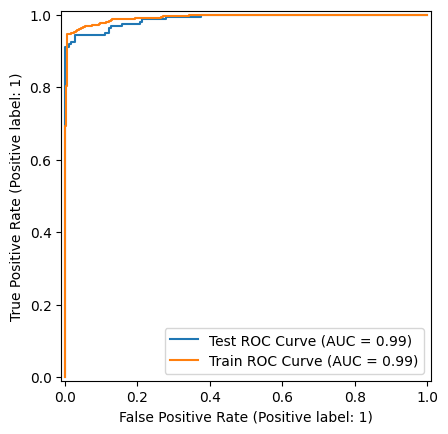

In [365]:
ax = plt.gca()
test_disp = RocCurveDisplay.from_estimator(clf_lr_w_final, X_test_2c, y_test_2c, ax=ax, name="Test ROC Curve")
train_disp = RocCurveDisplay.from_estimator(clf_lr_w_final, X_train_2c, y_train_2c, ax=ax, name="Train ROC Curve")
plt.savefig("task2_roc_weights.png",bbox_inches = 'tight')   
plt.show()

−Generate and plot the confusion matrix.

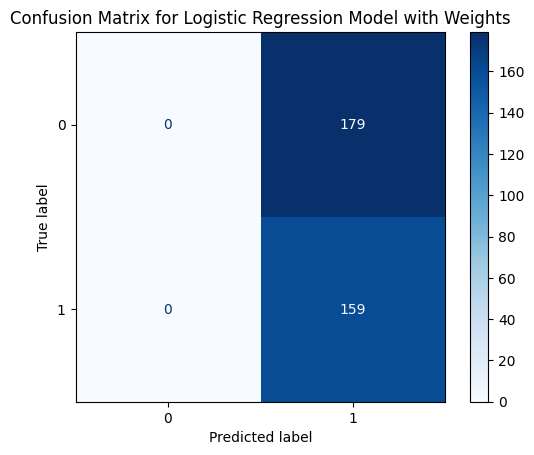

In [366]:
cm = confusion_matrix(y_test_2c, y_prediction_w_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Model with Weights")
plt.savefig("task2_confusion_weights.png",bbox_inches = 'tight') 
plt.show()


<br>Questions :
<br>1) What differences do you find between train and test ROC curves in the logistic regression model?
<br>2) What does the confusion matrix represent?
<br>3) How do the weights influence the results of our classification in logistic regression?
<br>4) What metrics are good to use to compare models? How can you decide what is a good model?

## Task 3: Binary classification with SVM

In this task you will develop multiple support vector classifiers (SVC) for the binary classification task. 
<br> -Develop and train a linear SVC with the given parameters [C=1.0, coef0=0.0, tol=1e-3]. (Note: default kernel is RBF and must be changed to linear)

In [367]:
from sklearn.svm import SVC

In [368]:
clf_svmlin = SVC(C=1.0, kernel='linear', coef0=0.0, tol=1e-3)
clf_svmlin.fit(X_train_2c, y_train_2c)
y_prediction_svmlin = clf_svmlin.predict(X_test_2c)

−Calculate and print the following performance metrics: Accuracy, recall, precision, and F1 score.

In [369]:
#Performance metrics
Accuracy_svmlin = accuracy_score(y_test_2c, y_prediction_svmlin)
F1_svmlin = f1_score(y_test_2c, y_prediction_svmlin)
Precision_svmlin = precision_score(y_test_2c, y_prediction_svmlin)
Recall_svmlin = recall_score(y_test_2c, y_prediction_svmlin)
print("Accuracy: " + str(Accuracy_svmlin))
print("F1 score: " + str(F1_svmlin))
print("Recall score: " + str(Recall_svmlin))
print("Precision score: " + str(Precision_svmlin))

Accuracy: 0.9733727810650887
F1 score: 0.970873786407767
Recall score: 0.9433962264150944
Precision score: 1.0


−Plot receiver operating characteristics (ROC) curve of training and test data in the same figure.

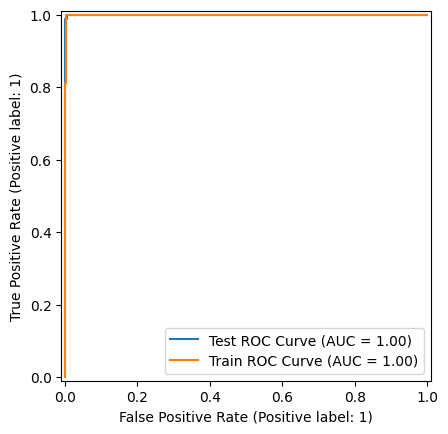

In [370]:
ax = plt.gca()
test_disp = RocCurveDisplay.from_estimator(clf_svmlin, X_test_2c, y_test_2c, ax=ax, name="Test ROC Curve")
train_disp = RocCurveDisplay.from_estimator(clf_svmlin, X_train_2c, y_train_2c, ax=ax, name="Train ROC Curve")
plt.savefig("task3_linear_roc.png",bbox_inches = 'tight')   
plt.show()

−Generate and plot the confusion matrix.

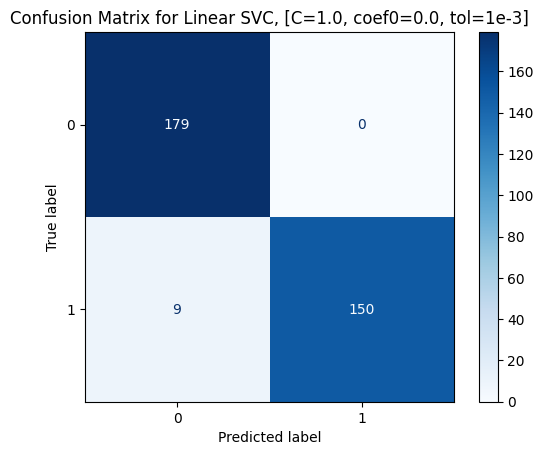

In [371]:
cm = confusion_matrix(y_test_2c, y_prediction_svmlin)
#print("Confusion Matrix for SVM with [C=1.0, coef0=0.0, tol=1e-3]:")
#print(cm)
cm = confusion_matrix(y_test_2c, y_prediction_svmlin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Linear SVC, [C=1.0, coef0=0.0, tol=1e-3]")
plt.savefig("task3_linear.png",bbox_inches = 'tight') 
plt.show()

Next step, you will investigate the impact of hyperparameters. The regularization parameter (C) adjusts the penalty factor for samples in training.
<br>-Develop two linear SVCs, one with parameter C as 0.0001 and one with C as 100, then train both models. (tol=1e-3)


In [372]:
#SVC construction for C=0.0001 and C=100
clf_svmlin2 = SVC(C=0.0001, kernel='linear', coef0=0.0, tol=1e-3)
clf_svmlin2.fit(X_train_2c, y_train_2c)
y_prediction_svmlin2 = clf_svmlin2.predict(X_test_2c)
clf_svmlin3 = SVC(C=100, kernel='linear', coef0=0.0, tol=1e-3)
clf_svmlin3.fit(X_train_2c, y_train_2c)
y_prediction_svmlin3 = clf_svmlin3.predict(X_test_2c)

−Calculate and print the following performance metrics for both cases: Accuracy, recall, precision, and F1 score.

In [373]:
#Performance metrics C=0.0001
Accuracy_svmlin2 = accuracy_score(y_test_2c, y_prediction_svmlin2)
F1_svmlin2 = f1_score(y_test_2c, y_prediction_svmlin2)
Precision_svmlin2 = precision_score(y_test_2c, y_prediction_svmlin2)
Recall_svmlin2 = recall_score(y_test_2c, y_prediction_svmlin2)
print("Accuracy: " + str(Accuracy_svmlin2))
print("F1 score: " + str(F1_svmlin2))
print("Recall score: " + str(Recall_svmlin2))
print("Precision score: " + str(Precision_svmlin2))

Accuracy: 0.5473372781065089
F1 score: 0.07272727272727272
Recall score: 0.03773584905660377
Precision score: 1.0


In [374]:
#Performance metrics C=100
Accuracy_svmlin3 = accuracy_score(y_test_2c, y_prediction_svmlin3)
F1_svmlin3 = f1_score(y_test_2c, y_prediction_svmlin3)
Precision_svmlin3 = precision_score(y_test_2c, y_prediction_svmlin3)
Recall_svmlin3 = recall_score(y_test_2c, y_prediction_svmlin3)
print("Accuracy: " + str(Accuracy_svmlin3))
print("F1 score: " + str(F1_svmlin3))
print("Recall score: " + str(Recall_svmlin3))
print("Precision score: " + str(Precision_svmlin3))

Accuracy: 0.985207100591716
F1 score: 0.9841269841269841
Recall score: 0.9748427672955975
Precision score: 0.9935897435897436


−	Plot the receiver operating characteristic (ROC) curves for both cases separately.

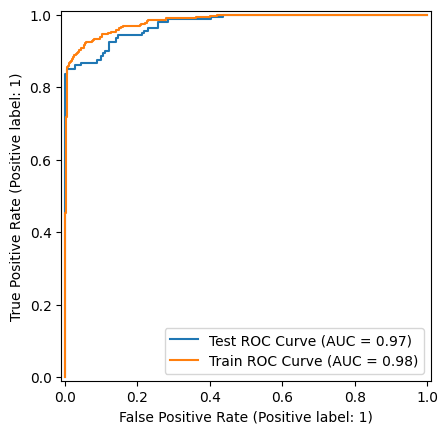

In [375]:
#ROC curve for C=0.0001
ax = plt.gca()
test_disp = RocCurveDisplay.from_estimator(clf_svmlin2, X_test_2c, y_test_2c, ax=ax, name="Test ROC Curve")
train_disp = RocCurveDisplay.from_estimator(clf_svmlin2, X_train_2c, y_train_2c, ax=ax, name="Train ROC Curve")
plt.savefig("task3_linear_roc2.png",bbox_inches = 'tight')   
plt.show()

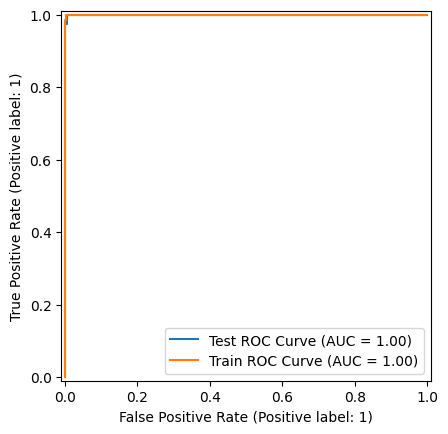

In [376]:
#ROC curve for C=0.0001
ax = plt.gca()
test_disp = RocCurveDisplay.from_estimator(clf_svmlin3, X_test_2c, y_test_2c, ax=ax, name="Test ROC Curve")
train_disp = RocCurveDisplay.from_estimator(clf_svmlin3, X_train_2c, y_train_2c, ax=ax, name="Train ROC Curve")
plt.savefig("task3_linear_roc3.png",bbox_inches = 'tight')   
plt.show()

−	Generate and plot the confusion matrices for both cases separately.

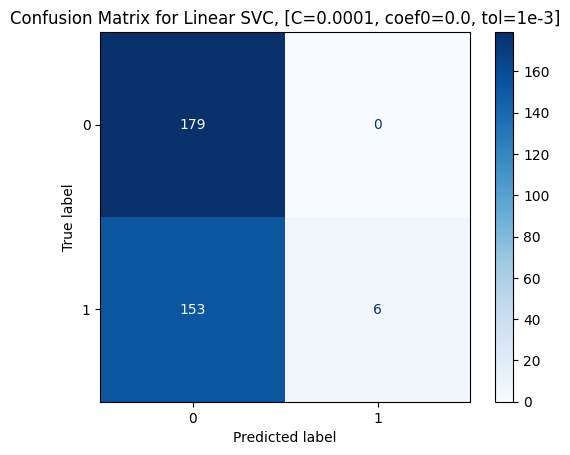

In [377]:
#Confusion matrix C=0.0001
cm = confusion_matrix(y_test_2c, y_prediction_svmlin2)
#print("Confusion Matrix for SVM with [C=0.0001, coef0=0.0, tol=1e-3]:")
#print(cm)
cm = confusion_matrix(y_test_2c, y_prediction_svmlin2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Linear SVC, [C=0.0001, coef0=0.0, tol=1e-3]")
plt.savefig("task3_linear2.png",bbox_inches = 'tight') 
plt.show()

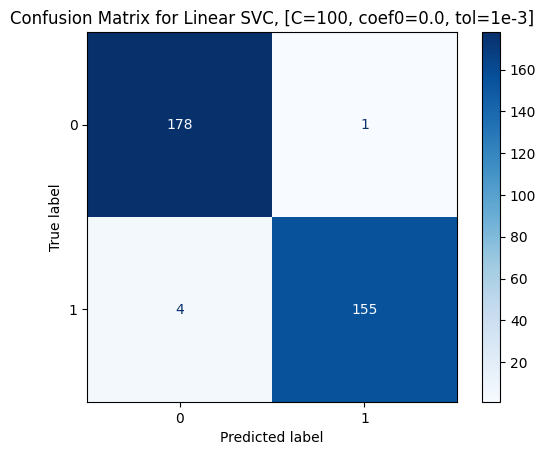

In [378]:
#Confusion matrix C=100
cm = confusion_matrix(y_test_2c, y_prediction_svmlin3)
#print("Confusion Matrix for SVM with [C=100, coef0=0.0, tol=1e-3]:")
#print(cm)
cm = confusion_matrix(y_test_2c, y_prediction_svmlin3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Linear SVC, [C=100, coef0=0.0, tol=1e-3]")
plt.savefig("task3_linear3.png",bbox_inches = 'tight') 
plt.show()

The other tunable hyperparameter is tolerance which adjusts the stopping criteria of the optimizer. 
<br>−	Develop and train a linear SVC with the given parameters [C=1.0, coef0=0.0, tol=10]. 


In [379]:
#Tolerance 10
clf_svmlin4 = SVC(C=1.0,kernel='linear', coef0=0.0, tol=10)
clf_svmlin4.fit(X_train_2c, y_train_2c)
y_prediction_svmlin4 = clf_svmlin4.predict(X_test_2c)

In [380]:
#Performance metrics tolerance 10
Accuracy_svmlin4 = accuracy_score(y_test_2c, y_prediction_svmlin4)
F1_svmlin4 = f1_score(y_test_2c, y_prediction_svmlin4)
Precision_svmlin4 = precision_score(y_test_2c, y_prediction_svmlin4)
Recall_svmlin4 = recall_score(y_test_2c, y_prediction_svmlin4)
print("Accuracy: " + str(Accuracy_svmlin4))
print("F1 score: " + str(F1_svmlin4))
print("Recall score: " + str(Recall_svmlin4))
print("Precision score: " + str(Precision_svmlin4))

Accuracy: 0.47041420118343197
F1 score: 0.6398390342052314
Recall score: 1.0
Precision score: 0.47041420118343197


−Plot receiver operating characteristics (ROC) curve of training and test data in the same figure.

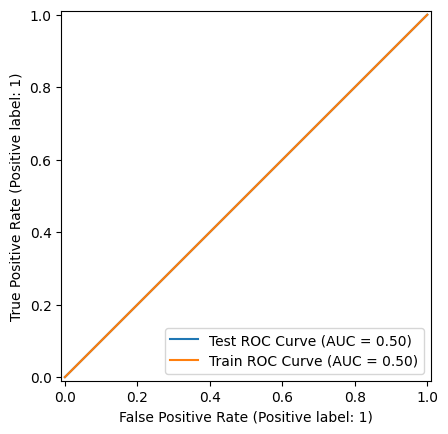

In [381]:
#ROC curve for tolerance 10
ax = plt.gca()
test_disp = RocCurveDisplay.from_estimator(clf_svmlin4, X_test_2c, y_test_2c, ax=ax, name="Test ROC Curve")
train_disp = RocCurveDisplay.from_estimator(clf_svmlin4, X_train_2c, y_train_2c, ax=ax, name="Train ROC Curve")
plt.savefig("task3_linear_roc4.png",bbox_inches = 'tight')   
plt.show()

−Generate and plot the confusion matrix.

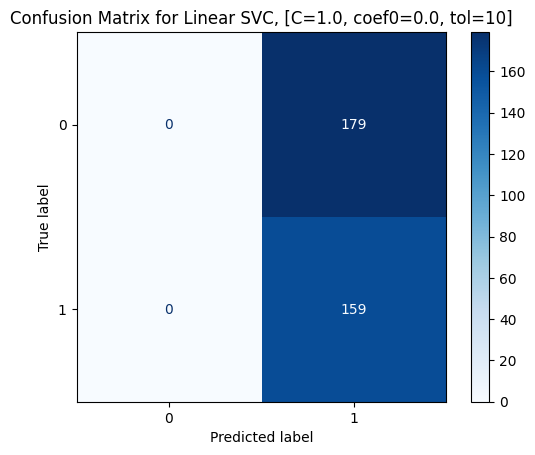

In [382]:
#Confusion matrix tolerance 10
cm = confusion_matrix(y_test_2c, y_prediction_svmlin4)
#print("Confusion Matrix for SVM with [C=1.0, coef0=0.0, tol=10]:")
#print(cm)
cm = confusion_matrix(y_test_2c, y_prediction_svmlin4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Linear SVC, [C=1.0, coef0=0.0, tol=10]")
plt.savefig("task3_linear4.png",bbox_inches = 'tight') 
plt.show()

Kernels are decision functions applied to transform the feature space into higher dimensions. Nonlinear relationships between features can be found in high-dimensional space. In this CodeLab you will use a polynomial SVC (SVM classifier with a polynomial kernel). 
<br> −Develop and train two polynomial SVCs [kernel=’poly’] one with the degree of 3 and one with the degree of 2.  [C=1.0, coef0=0.0, tol=1e-3]. 

In [383]:
#Polynomial SVM with 2nd and 3rd degree. 
clf_svmpoly1 = SVC(C=1.0, kernel='poly', degree=2, coef0=0.0, tol=1e-3)
clf_svmpoly1.fit(X_train_2c, y_train_2c)
y_prediction_svmpoly1 = clf_svmpoly1.predict(X_test_2c)

clf_svmpoly2 = SVC(C=1.0, kernel='poly', degree=3, coef0=0.0, tol=1e-3)
clf_svmpoly2.fit(X_train_2c, y_train_2c)
y_prediction_svmpoly2 = clf_svmpoly2.predict(X_test_2c)

−Calculate and print the following performance metrics for both cases: Accuracy, recall, precision, and F1 score.

In [384]:
#Performance metrics polynomial 2nd
Accuracy_svmpoly = accuracy_score(y_test_2c, y_prediction_svmpoly1)
F1_svmpoly = f1_score(y_test_2c, y_prediction_svmpoly1)
Precision_svmpoly = precision_score(y_test_2c, y_prediction_svmpoly1)
Recall_svmpoly = recall_score(y_test_2c, y_prediction_svmpoly1)
print("Accuracy: " + str(Accuracy_svmpoly))
print("F1 score: " + str(F1_svmpoly))
print("Recall score: " + str(Precision_svmpoly))
print("Precision score: " + str(Recall_svmpoly))

Accuracy: 0.8757396449704142
F1 score: 0.8478260869565217
Recall score: 1.0
Precision score: 0.7358490566037735


In [385]:
#Performance metrics polynomial 3rd
Accuracy_svmpoly2 = accuracy_score(y_test_2c, y_prediction_svmpoly2)
F1_svmpoly2 = f1_score(y_test_2c, y_prediction_svmpoly2)
Precision_svmpoly2 = precision_score(y_test_2c, y_prediction_svmpoly2)
Recall_svmpoly2 = recall_score(y_test_2c, y_prediction_svmpoly2)
print("Accuracy: " + str(Accuracy_svmpoly2))
print("F1 score: " + str(F1_svmpoly2))
print("Recall score: " + str(Precision_svmpoly2))
print("Precision score: " + str(Recall_svmpoly2))

Accuracy: 0.9349112426035503
F1 score: 0.9261744966442953
Recall score: 0.9928057553956835
Precision score: 0.8679245283018868


−	Generate and plot the confusion matrices for both cases separately.

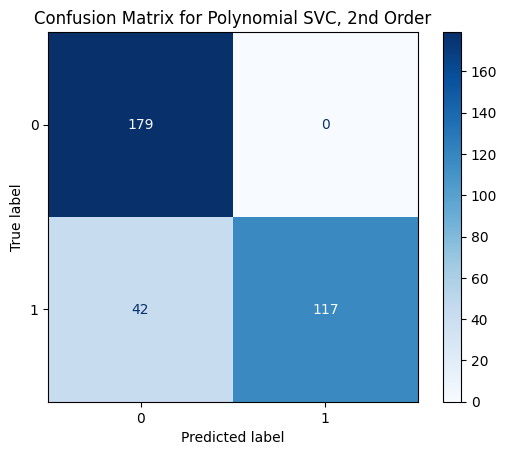

In [386]:
#Confusion matrix poly 2nd
cm = confusion_matrix(y_test_2c, y_prediction_svmpoly1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Polynomial SVC, 2nd Order")
plt.savefig("task3_poly2.png",bbox_inches = 'tight') 
plt.show()

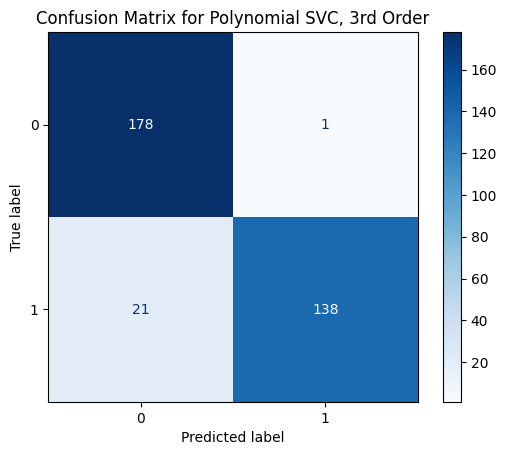

In [387]:
#Confusion matrix poly 3rd
cm = confusion_matrix(y_test_2c, y_prediction_svmpoly2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Polynomial SVC, 3rd Order")
plt.savefig("task3_poly3.png",bbox_inches = 'tight') 
plt.show()

Questions 
<br> 1) Compare linear SVM and logistic regression models.
<br> 2) What did you observe when parameter C is varied? Explain the role of parameter C in SVC.
<br> 3) What did you observe when tolerance is changed to 10? Explain the role of parameter tolerance in SVC.
<br> 4) Which SVM model do you prefer for this problem, polynomial or linear kernel?  Why? What is the potential benefit of using a nonlinear kernel? 
<br> 5) Rank the models from the highest performance to the lowest one with F1 scores.


## Task 4: Multi-class classification

Multi-class classification predicts the best among a set of labels (four, in this case). We consider two different model classes (logistic regression and SVM) and within the logistic regression model, both the One vs. All and the multi-class approach. 
<br> The One vs. All (called ‘one versus rest’ in sklearn) method constructs binary classifiers for each class. The final prediction is based on the model with the highest score or the largest (signed) distance from the classification boundary. 

<br>-Split the data (X, and y_mc) into training (75%) and test sets (25%) using the “train_test_split” function from Sklearn. Use 4720 as the random state parameter to control the split.  

In [388]:
import time

In [389]:
#Train test split (use the multi-channel classificaiton so y_mc ones)
Shuffle_state = 4720
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(X_scaled, y_mc_data_int, test_size=0.25, random_state=4720, shuffle=True)

-Develop and train a logistic regression model using the one vs. rest (parameter multi_class=’ovr’) method using the “y_mc” label vector. 

In [390]:
#Logistic regression 
start_time = time.time()
clf_lr_ovr = LogisticRegression(multi_class='ovr') #on default max_iter=100
clf_lr_ovr.fit(X_train_mc, y_train_mc)
y_prediction_lrovr = clf_lr_ovr.predict(X_test_mc)
ovr_time = time.time() - start_time

/opt/anaconda3/envs/CodeLab1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


−	Calculate and print the accuracy of the model. 

In [391]:
#Accuracy of OVR LR
Accuracy_lrovr = accuracy_score(y_test_mc, y_prediction_lrovr)
print("Accuracy: " + str(Accuracy_lrovr))

Accuracy: 0.8698224852071006


−Generate and plot the confusion matrix.

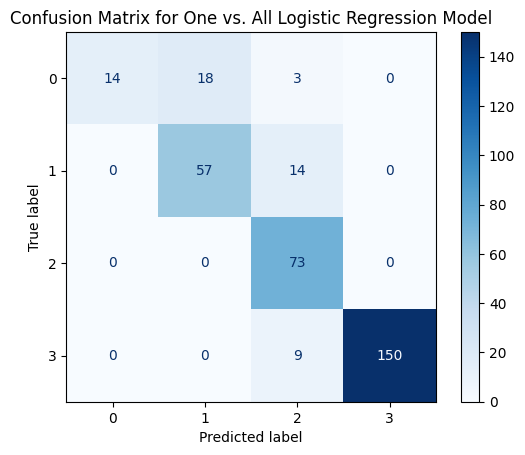

In [392]:
#Confusion matrix OVR LR
cm = confusion_matrix(y_test_mc, y_prediction_lrovr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for One vs. All Logistic Regression Model")
plt.savefig("task4_1.png",bbox_inches = 'tight') 
plt.show()

For logistic regression, we can also directly train a multi-class classifier using the multi-class cross-entropy loss (sklearn calls this the multinomial cross-entropy loss).  
<br>−Develop and train a multi-class logistic regression model (parameter multi_class=’multinomial’)


In [393]:
start_time = time.time()
clf_lr_mult = LogisticRegression(multi_class='multinomial')
clf_lr_mult.fit(X_train_mc, y_train_mc)
y_prediction_lrmult = clf_lr_mult.predict(X_test_mc)
mult_time = time.time() - start_time

/opt/anaconda3/envs/CodeLab1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


−	Calculate and print the accuracy of the model. 

In [394]:
#Accuracy of Mult LR
Accuracy_lrmult = accuracy_score(y_test_mc, y_prediction_lrmult)
print("Accuracy: " + str(Accuracy_lrmult))

Accuracy: 0.9171597633136095


−Generate and plot the confusion matrix.

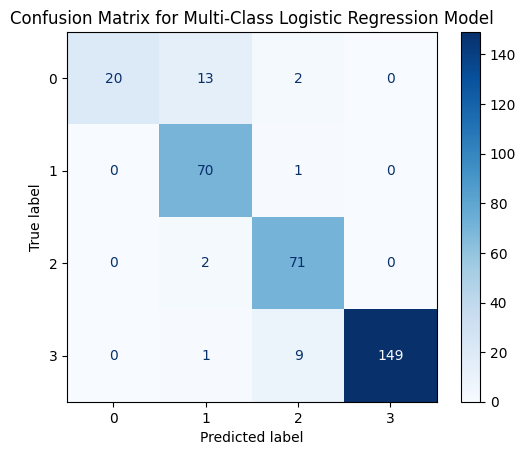

In [395]:
#Confusion matrix mult LR
cm = confusion_matrix(y_test_mc, y_prediction_lrmult)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Multi-Class Logistic Regression Model")
plt.savefig("task4_2.png",bbox_inches = 'tight') 
plt.show()

SVM can be used in multi-class classification tasks as well, but it will rely on the one-versus-all approach (or, for non-linear kernels, on the related one-versus-one approach). 

<br> - Develop and train a linear SVC [kernel=’linear’] as a one vs. all classifier with the given parameters [C=1.0, coef0=0.0, tol=1e-3]. 

In [396]:
#OVR SVM
start_time = time.time()
clf_svmlin_mc_ovr = SVC(C=1.0, kernel='linear', coef0=0.0, tol=1e-3)
clf_svmlin_mc_ovr.fit(X_train_mc, y_train_mc)
y_prediction_svmovr = clf_svmlin_mc_ovr.predict(X_test_mc)
svm_time = time.time() - start_time

−	Calculate and print the accuracy of the model. 

In [397]:
#Accuracy of SVM
Accuracy_svmovr = accuracy_score(y_test_mc, y_prediction_svmovr)
print("Accuracy: " + str(Accuracy_svmovr))

Accuracy: 0.9497041420118343


−Generate and plot the confusion matrix.

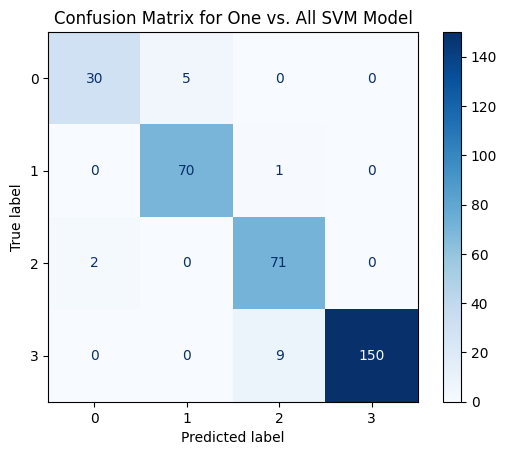

In [398]:
#Confusion matrix SVM OVR
cm = confusion_matrix(y_test_mc, y_prediction_svmovr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for One vs. All SVM Model")
plt.savefig("task4_3.png",bbox_inches = 'tight') 
plt.show()

In [399]:
print(f"Time for One-vs-All Logistic Regression: {ovr_time:.4f} seconds")
print(f"Time for Multi-Class Logistic Regression: {mult_time:.4f} seconds")
print(f"Time for One-vs-All SVM: {svm_time:.4f} seconds")

Time for One-vs-All Logistic Regression: 0.0239 seconds
Time for Multi-Class Logistic Regression: 0.0169 seconds
Time for One-vs-All SVM: 0.0161 seconds


Questions:
<br>1) How does the performance change for both classification methods for the logistic regression and why?
<br>2) Which classification method is more computationally demanding and why? 
<br>3) Why other classification metrics cannot be used directly in multi-class classification tasks?
<br>4) Why can multi-class classification be directly applied to logistic regression but not SVM?
<br>5) Compare all three models’ performance in multi-class classification.
<br>6) Which classes have higher mismatches in logistic regression? 
<br>7) Which classes have higher mismatches in SVM?  


### Bonus Task

Conduct a multi-class classification using only binary classifiers. You can use either logistic regression or SVM. Describe the steps you follow and how it works. Calculate each classifier’s output probabilities for the test data and plot them in ascending order.  

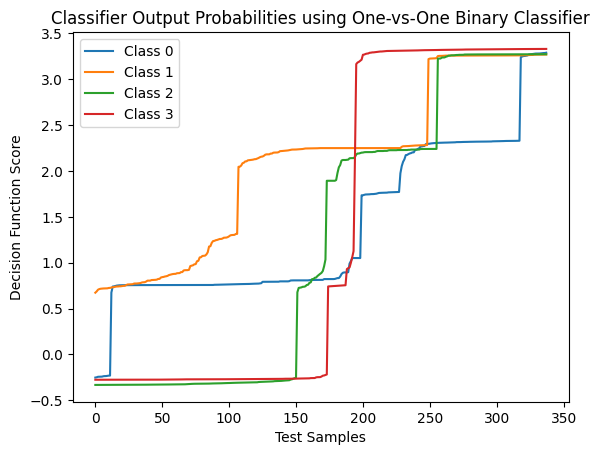

In [401]:
from sklearn.multiclass import OneVsOneClassifier
# Assume X and y_mc are your feature matrix and multiclass labels
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_mc_data_int, test_size=0.25, random_state=4720)

# Logistic Regression with One-vs-One Strategy
ovo_clf = OneVsOneClassifier(LogisticRegression())
ovo_clf.fit(X_train, y_train)

# Predict probabilities on test set
probabilities = ovo_clf.decision_function(X_test)

# Sort and plot the probabilities
for i in range(probabilities.shape[1]):
    sorted_probs = sorted(probabilities[:, i])  # Sort the probabilities in ascending order
    plt.plot(sorted_probs, label=f'Class {i}')
plt.title("Classifier Output Probabilities using One-vs-One Binary Classifier")
plt.xlabel("Test Samples")
plt.ylabel("Decision Function Score")
plt.legend()
plt.savefig("task_bonus.png",bbox_inches = 'tight') 
plt.show()